In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/python")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
from matplotlib.offsetbox import AnchoredText
%matplotlib inline
from _corner import corner
import pickle
from scipy.stats import gaussian_kde, binned_statistic, binned_statistic_2d
from scipy.interpolate import UnivariateSpline, griddata
from scipy.optimize import minimize

from matplotlib import rc
rc('font', family='times new roman', size=18.)

We have finally decided that we are not going Bayesian, so only interested in likelihood results

# gNFW

In [2]:
from utils_preprocessing import  profile_L_interval


def plotting_like(samples, index):
    
    LI_max = samples[index][np.argmax(samples[3])]
    bin_n=60
    LI_low, LI_high = profile_L_interval(samples[3], samples[index], bin_n=bin_n)

    _bin = binned_statistic(samples[index], -samples[3], 'min', bins=bin_n)
    like    = _bin[0]
    x_edges = _bin[1]
    x_bin = []
    for i in range(len(x_edges)-1):
        x_bin.append((x_edges[i+1] + x_edges[i])*0.5)
    
    return like, x_bin, LI_max, LI_low, LI_high

Text(0.5, 0, 'Rs [kpc]')

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


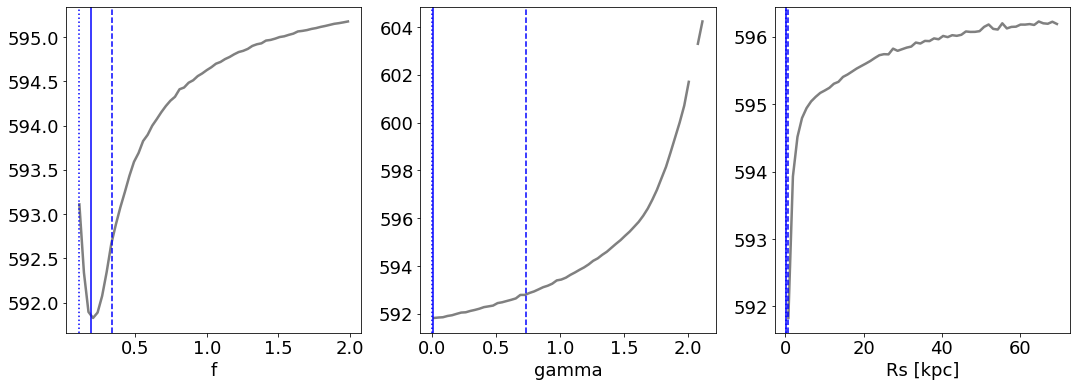

In [3]:
filepath ="/home/mariacst/exoplanets/running/gNFW/baseline_NL/out/"
nBDs=100; rank=89; gamma=1.5; sigma=0.1; ex="baseline_NL_gNFW"
_file    = filepath + "%i/"%rank + ex + "_N%i_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(nBDs, sigma, gamma, rank)
samples = np.genfromtxt(_file, unpack=True)


fig, ax = plt.subplots(1, 3, figsize=(18, 6))

like, x_bin, LI_max, LI_low, LI_high = plotting_like(samples, 0)
ax[0].plot(x_bin, like, lw=2.5, color="grey")
ax[0].axvline(LI_max, color="blue"); ax[0].axvline(LI_low, ls=":", color="blue")
ax[0].axvline(LI_high, ls="--", color="blue"); ax[0].set_xlabel("f")

like, x_bin, LI_max, LI_low, LI_high = plotting_like(samples, 1)
ax[1].plot(x_bin, like, lw=2.5, color="grey")
ax[1].axvline(LI_max, color="blue"); ax[1].axvline(LI_low, ls=":", color="blue")
ax[1].axvline(LI_high, ls="--", color="blue"); ax[1].set_xlabel("gamma")

like, x_bin, LI_max, LI_low, LI_high = plotting_like(samples, 2)
ax[2].plot(x_bin, like, lw=2.5, color="grey")
ax[2].axvline(LI_max, color="blue"); ax[2].axvline(LI_low, ls=":", color="blue")
ax[2].axvline(LI_high, ls="--", color="blue"); ax[2].set_xlabel("Rs [kpc]")

In [61]:
data = binned_statistic_2d(samples[1], samples[2], -samples[3], statistic="min", bins=(10, 5), 
                           expand_binnumbers=True)
like=data[0]; x_edge=data[1]; y_edge=data[2]
x_bin=[]; y_bin=[]
for i in range(len(x_edge)-1):
    x_bin.append((x_edge[i+1]+x_edge[i])*0.5)
for i in range(len(y_edge)-1):
    y_bin.append((y_edge[i+1]+y_edge[i])*0.5)

10 5 (10, 5)


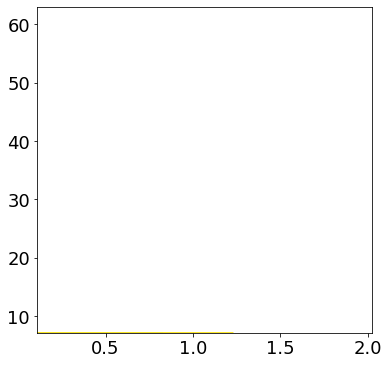

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
print(len(x_bin), len(y_bin), like.shape)
like[np.isnan(like)] = np.min(like[~np.isnan(like)])*10
ax.contour(x_bin, y_bin, like.T, levels=(np.min(like), 
                                         np.min(like)+1, 
                                         np.min(like)+2,))

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:55: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "background" which is no longer supported as of 3.3 and will become an error two minor releases later


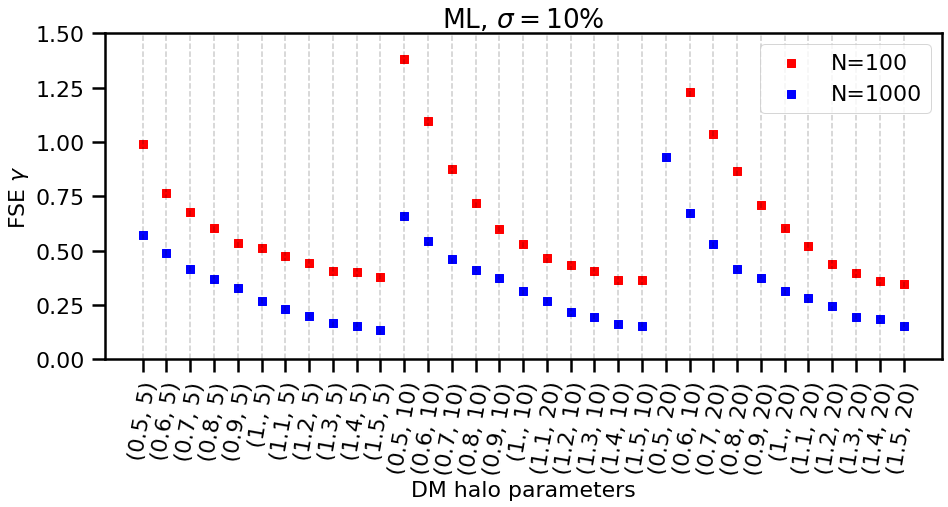

In [10]:
import imp
import utils_plots
imp.reload(utils_plots)

from utils_plots import FSE_f_gamma_rs_gNFW


#IMPORTANT CHANGE UTILS_PLOTS INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/gNFW/"

nBDs = [100, 1000]
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

j=0

fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
i=0
for N in nBDs:
    xi, yi, zi = FSE_f_gamma_rs_gNFW(path, N, sigma, "baseline_NL_gNFW", _gamma=True)    
    ax.scatter(x1, np.ravel(zi), color=color[i], marker="s", label="N=%i"%N, s=70.)
    
    i+=1
j+=1

for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x1:
    ax.axvline(i, ls="--", alpha=0.2, color="k")

ax.legend()
ax.set_xticks(x1) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

ax.set_ylim(0, 1.)
ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
ax.set_ylim(0., 1.5)
fig.savefig("baseline_NL_gNFW_sigma%.1f.png"%sigma, bbox_inches="tight", background="transparent")

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator


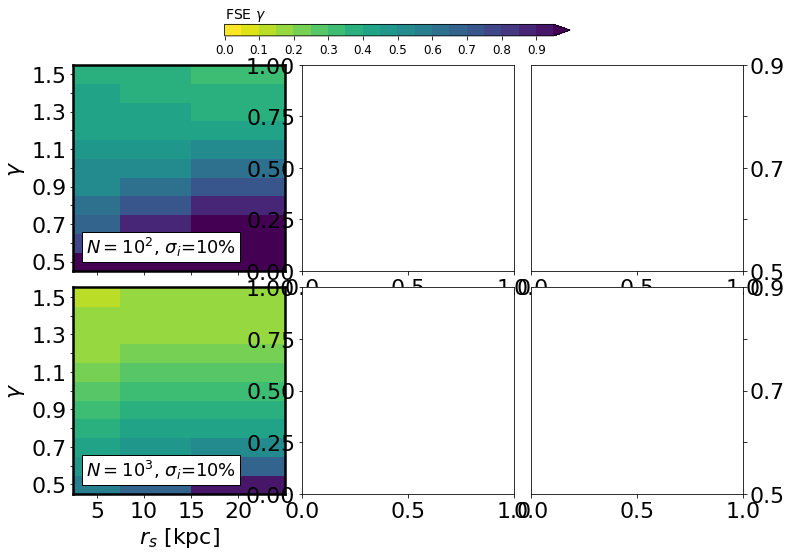

In [22]:
import utils_plots
imp.reload(utils_plots)
from utils_plots import grid_FSE

path = "/home/mariacst/exoplanets/results/gNFW/"
ex   = "baseline_NL_gNFW"


fig, ax = plt.subplots(2, 3, figsize=(12, 8))
cs = grid_FSE(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False, gNFW=True, _gamma=True)
grid_FSE(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True, gNFW=True, _gamma=True)
#grid_FSE(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False, gNFW=True, _gamma=True)
#grid_FSE(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True, gNFW=True, _gamma=True)
#grid_FSE(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False, gNFW=True, _gamma=True)
#grid_FSE(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True, gNFW=True, _gamma=True)
#ax[0, 0].set_title(pe)
ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()

fig.subplots_adjust(top=0.87)
cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")

#fig.subplots_adjust(right=0.87)
#cbar_ax = fig.add_axes([0.94, 0.2, 0.01, 0.4])
#cbar = fig.colorbar(cs, cax=cbar_ax)

cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")

fig.subplots_adjust(wspace=0.08, hspace=0.08)

#fig.savefig("FSE_" + ex + pe + ".png", transparent=True)

# Power-law

In [60]:
#filepath = "/hdfs/local/mariacst/exoplanets/results/multinest/onlySigmaT/power_law/
filepath ="/home/mariacst/exoplanets/running/baseline/non_linear/out/extra_wider/"
rank =8; gamma=1.5; sigma=0.3
_file    = filepath + "%i/baseline_multinest_N100_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
samples1 = np.genfromtxt(_file, unpack=True)

#filepath ="/home/mariacst/exoplanets/debug/multinest/power_law/non_linear/out/extra_wider/"
#_file    = filepath + "%i/T650_multinest_N100_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
#samples2 = np.genfromtxt(_file, unpack=True)

'    \ncorner(np.array([samples2[0], samples2[1]]).T, \n                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, \n                   #range=((20, 100), (0.6, 2.)),\n                   plot_density=False, fill_contours=False, smooth=smooth, color="blue", fig=fig)\n\nfor axidx, samps in zip([0, 3], np.array([samples2[0], samples2[1]])):\n    kde   = gaussian_kde(samps)\n    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)\n    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="blue", lw=2.5) \n    \n    \nalphaMAP_L = -0.8105187892913819\nalphaMAP_NL = -0.9244355413789123\n\nfig.axes[3].axvline(alphaMAP_L, c="r");fig.axes[3].axvline(alphaMAP_NL, c="b")\n'

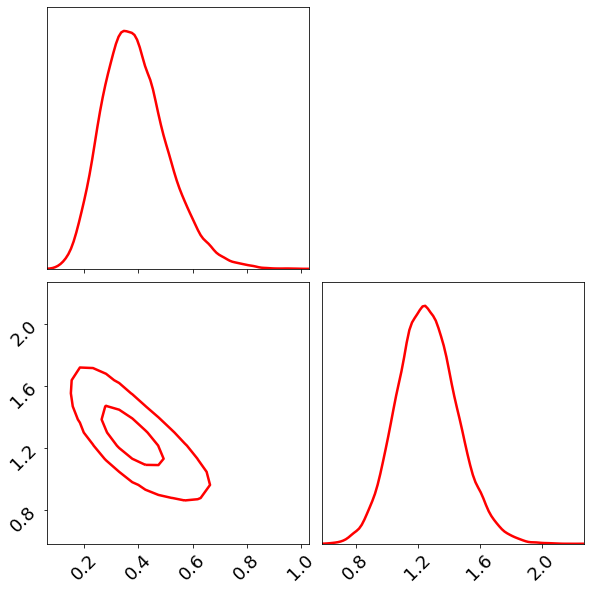

In [61]:
smooth=1.

fig, axes = corner(np.array([samples1[0], samples1[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   #range=((20, 100), (0.6, 2.)),
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 3], np.array([samples1[0], samples1[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   

"""    
corner(np.array([samples2[0], samples2[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   #range=((20, 100), (0.6, 2.)),
                   plot_density=False, fill_contours=False, smooth=smooth, color="blue", fig=fig)

for axidx, samps in zip([0, 3], np.array([samples2[0], samples2[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="blue", lw=2.5) 
    
    
alphaMAP_L = -0.8105187892913819
alphaMAP_NL = -0.9244355413789123

fig.axes[3].axvline(alphaMAP_L, c="r");fig.axes[3].axvline(alphaMAP_NL, c="b")
"""

In [2]:
import utils_plots
import imp
imp.reload(utils_plots)
from utils_plots import grid_FSE

NameError: name 'grid_FSE' is not defined

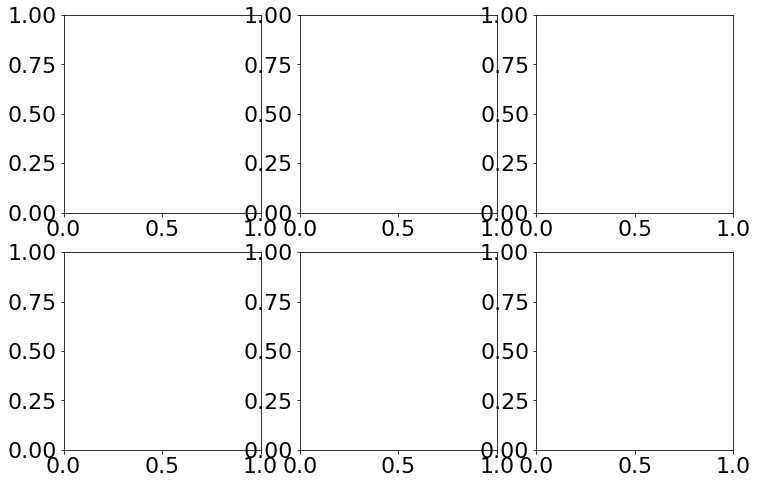

In [5]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "T650_log"

for pe in ["ML"]:#, "ML"]:
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    cs = grid_FSE(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_FSE(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True)
    grid_FSE(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    grid_FSE(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True)
    grid_FSE(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    grid_FSE(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True)
    #ax[0, 0].set_title(pe)
    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()
    #fig.subplots_adjust(wspace=0.1, hspace=0.1)
    #cbar = fig.colorbar(cs)
    cbar.set_label(r"FSE $\gamma^{{}}$".format(pe))
    
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")
    
    #fig.subplots_adjust(right=0.87)
    #cbar_ax = fig.add_axes([0.94, 0.2, 0.01, 0.4])
    #cbar = fig.colorbar(cs, cax=cbar_ax)
    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    #fig.savefig("FSE_" + ex + pe + ".png", transparent=True)

(0.0, 1.5)

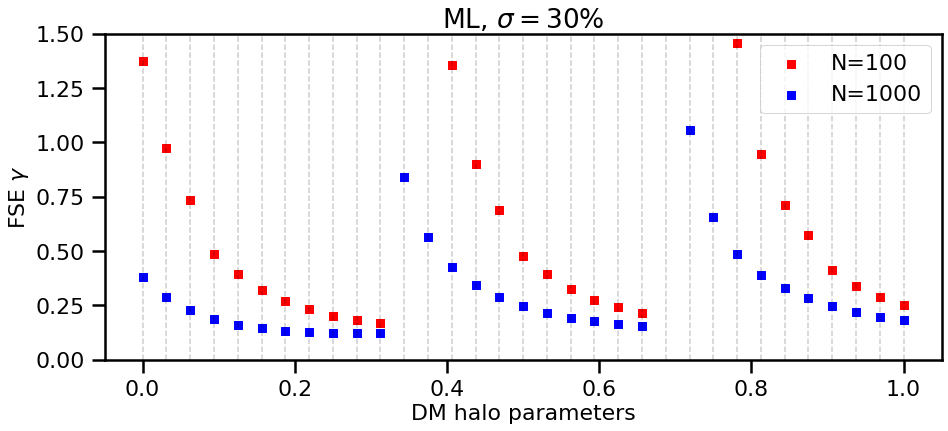

In [11]:
import imp
import utils_plots
imp.reload(utils_plots)

from utils_plots import FSE_f_gamma_rs


#IMPORTANT CHANGE UTILS_PLOTS INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/power_law/"

nBDs = [100, 1000]
sigma = 0.3

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33); #x2 = np.linspace(1.5, 2.5, 11)

pe     = "ML"
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

j=0
 
fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
i=0
for N in nBDs:
    xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_log", PE=pe)    
    ax.scatter(x1, np.ravel(zi), color=color[i], marker="s", label="N=%i"%N, s=70.)
    
    #xi, yi, zi = FSE_f_gamma_rs(path, N, 0.1, "T650_NL_log", PE=pe)    
    #ax.scatter(x2, np.ravel(zi)[:11], color=color[i], marker="o", s=70.)
    
    i+=1
j+=1

for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x1:
    ax.axvline(i, ls="--", alpha=0.2, color="k")
#for i in x2:
#    ax.axvline(i, ls="--", alpha=0.2, color="k")

ax.legend()
#ax.set_xticks(x)    

ax.set_ylim(0, 1.)
ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
ax.set_ylim(0., 1.5)
#fig.savefig("FSE_baseline_NL_PL_sigma%.1f.png"%sigma, bbox_inches="tight", background="transparent")

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:53: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "background" which is no longer supported as of 3.3 and will become an error two minor releases later


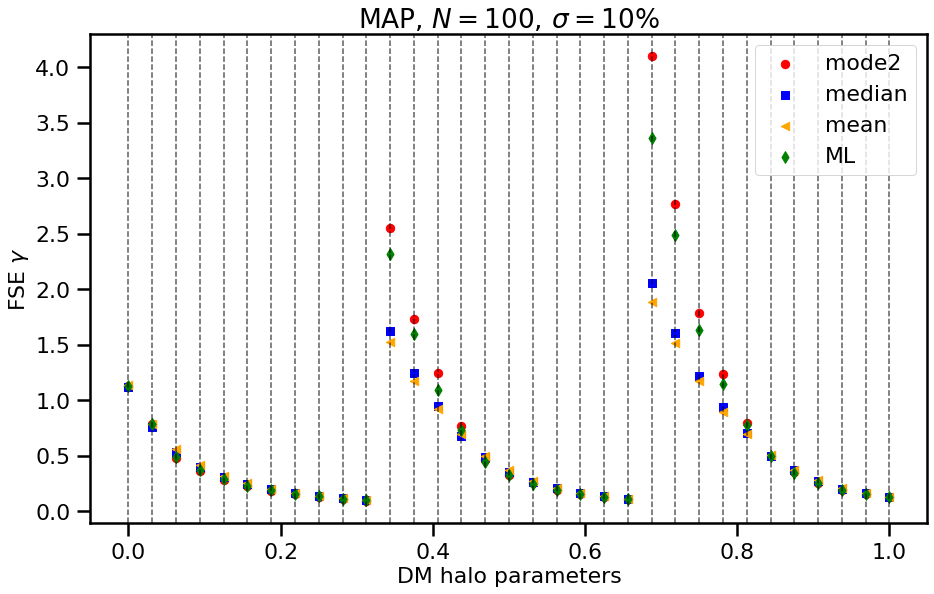

In [66]:
import imp
import utils_plots
imp.reload(utils_plots)

from utils_plots import FSE_f_gamma_rs


#IMPORTANT CHANGE UTILS_PLOTS INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/power_law/"

nBDs = [100]
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33); #x2 = np.linspace(1.5, 2.5, 11)

PE     = ["mode2", "median", "mean", "ML"]
color  = ["red", "blue", "orange", "green"]
marker = ["o", "s", "<", "d"]

j=0
fig, ax = plt.subplots(1, 1, figsize=(15, 9))    
i=0
for pe in PE:   
    for N in nBDs:
        xi, yi, zi = FSE_f_gamma_rs(path, N, 0.1, "baseline_NL_log", PE=pe) 
        #print(i, j)
        ax.scatter(x1, np.ravel(zi), color=color[j], marker=marker[j], label=pe, s=70.)
        
        #xi, yi, zi = FSE_f_gamma_rs(path, N, 0.1, "T650_NL_log", PE=pe)    
        #ax.scatter(x2, np.ravel(zi)[:11], color=color[i], marker="o", s=70.)
        
        i+=1
    j+=1
    
    for axis in ['top','bottom','left','right']:                                    
        ax.spines[axis].set_linewidth(2.5) 
    ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)
    
    for i in x1:
        ax.axvline(i, ls="--", alpha=0.2, color="k")
    #for i in x2:
    #    ax.axvline(i, ls="--", alpha=0.2, color="k")

    ax.legend()
    #ax.set_xticks(x)    

    ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
    ax.set_title(r"MAP, $N=%i,\,\sigma=%i$"%(N, int(sigma*100)) + "$\%$")
    #ax.set_ylim(0., 1.5)
fig.savefig("FSE_baseline_NL_nBDs%isigma%.1f_pointEstimates.png"%(N, sigma), bbox_inches="tight", background="transparent")

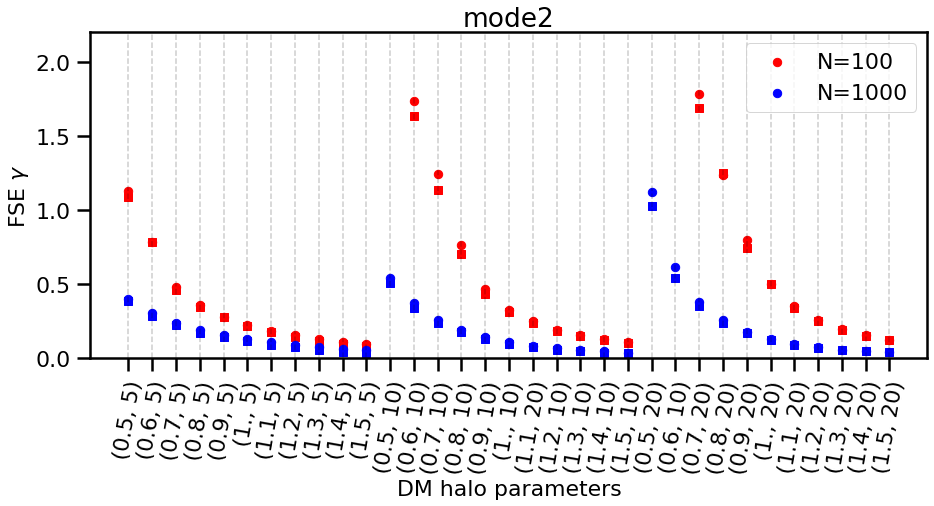

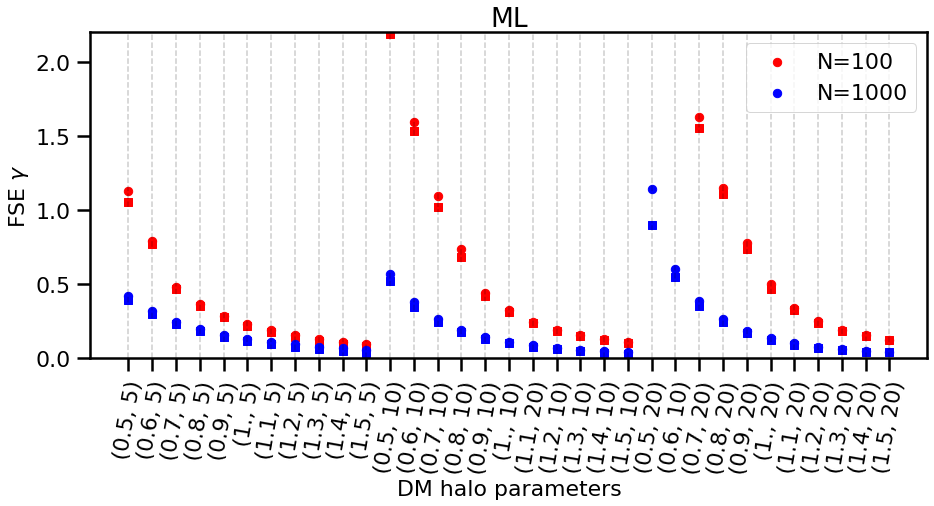

In [11]:
import imp
import utils_plots
imp.reload(utils_plots)

from utils_plots import FSE_f_gamma_rs


#IMPORTANT CHANGE UTILS_PLOTS INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/power_law/"

nBDs = [100, 1000]
sigma = 0.3


gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x     = np.linspace(0, 1, 33)

PE     = ["mode2", "ML"]#, "median", "mode2", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

j=0
for pe in PE:   
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
    i=0
    for N in nBDs:
        xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_log", PE=pe)    
        ax.scatter(x, np.ravel(zi), color=color[i], marker="o", label="N=%i"%N, s=70.)
        
        #xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "baseline_log", PE=pe)    
        #ax.scatter(x, np.ravel(zi), color=color[i], marker="s", s=70.)
        
        i+=1
    j+=1
    
    for axis in ['top','bottom','left','right']:                                    
        ax.spines[axis].set_linewidth(2.5) 
    ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)
    
    for i in x:
        ax.axvline(i, ls="--", alpha=0.2, color="k")

    ax.legend()
    ax.set_xticks(x)    

    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

    ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
    ax.set_title(pe)
    ax.set_ylim(0., 2.2)
    

#FSE_mean_100  = [0.597, 0.589, np.nan, np.nan, np.nan, np.nan, np.nan, 0.246, 0.208, 0.160, 0.115]
#FSE_mean_1000 = [0.731, 0.661, np.nan, np.nan, np.nan, np.nan, np.nan, 0.289, 0.246, 0.201, 0.154] 

#ax.scatter(x[:len(FSE_mean_100)], FSE_mean_100, color="red", marker="d")
#ax.scatter(x[:len(FSE_mean_1000)], FSE_mean_1000, color="blue", marker="d")

#fig.savefig(ex + "_FSE_gamma.png", bbox_inches="tight")

In [57]:
import utils_plots
import imp
imp.reload(utils_plots)
from utils_plots import grid_coverage

/home/mariacst/exoplanets/exoplanets/python/utils_plots.py:278: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im = ax.pcolormesh(xi, yi, zi, norm=norm, cmap=cmap)
/home/mariacst/exoplanets/exoplanets/python/utils_plots.py:290: UserWarning: The following kwargs were not used by contour: 'color'
  CS = ax.contour(xi_c, yi_c, zi_c.reshape(5, 13), levels=[0.68,], color="k")
/home/mariacst/exoplanets/exoplanets/python/utils_plots.py:296: UserWarning: FixedFormatter should only be used together with FixedLocator
  '', '1.5'])
/home/mariacst/exoplanets/exoplanets/python/utils_plots.py:301: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['5', '10', '15', '20'])
findfont: Font famil

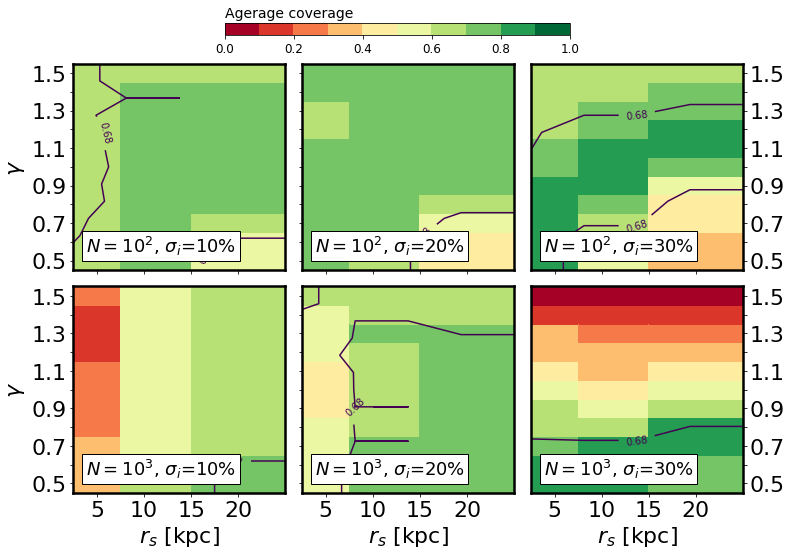

In [48]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "baseline_NL_log"

for pe in ["HPD"]:
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    cs = grid_coverage(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_coverage(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True)
    grid_coverage(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    grid_coverage(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True)
    grid_coverage(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    grid_coverage(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True)
    #ax[0, 0].set_title(pe)
    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()  
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"Agerage coverage", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    fig.savefig("coverage_" + ex + pe + ".png", transparent=True)

[[0.355 0.305 0.265 0.235 0.21  0.2   0.175 0.17  0.18  0.2   0.23 ]
 [0.62  0.585 0.58  0.555 0.55  0.545 0.535 0.525 0.505 0.52  0.555]
 [0.71  0.675 0.655 0.64  0.64  0.65  0.64  0.645 0.64  0.645 0.655]]


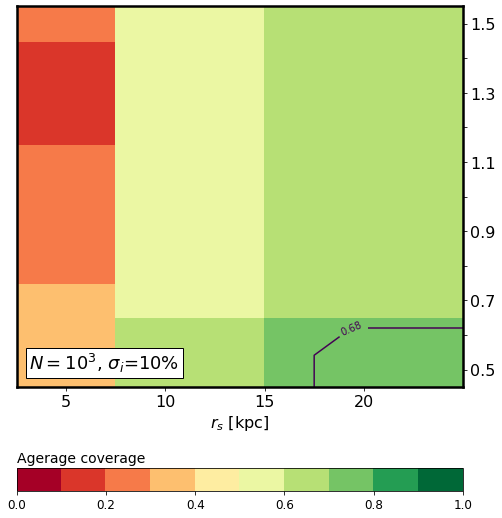

In [60]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "baseline_NL_log"

for pe in ["HPD"]:
    fig, ax = plt.subplots(1, 1, figsize=(8, 10))
    #cs = grid_coverage(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    cs = grid_coverage(path, 1000, 0.1, ex, ax, pe, ylabel=False, xlabel=True)

    #ax[0, 0].set_title(pe)
    ax.set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax.set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax.yaxis.tick_right(); ax.yaxis.tick_right()  

    cbar = fig.colorbar(cs, orientation="horizontal")    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"Agerage coverage", size=14., loc="left")
    

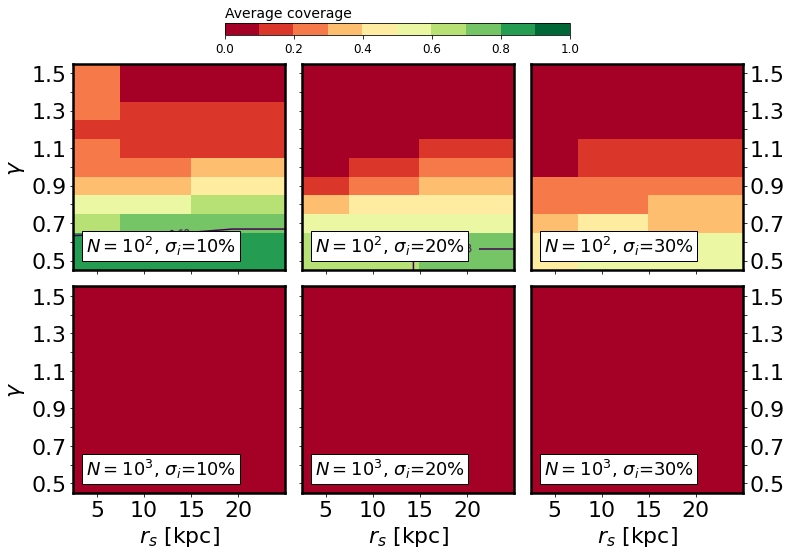

In [33]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "T650_log"

for pe in ["LI"]:
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    cs = grid_coverage(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_coverage(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True)
    grid_coverage(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    grid_coverage(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True)
    grid_coverage(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    grid_coverage(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True)
    #ax[0, 0].set_title(pe)
    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()  
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"Average coverage", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    fig.savefig("coverage_" + ex + pe + ".png", transparent=True)

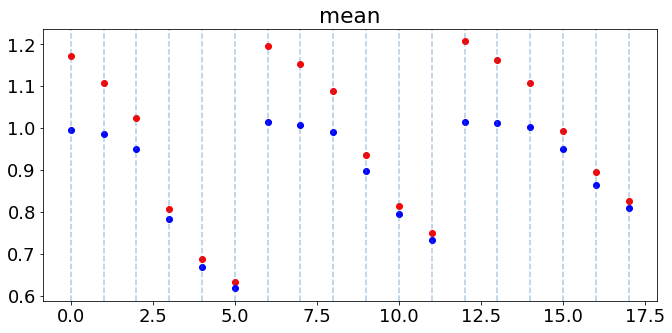

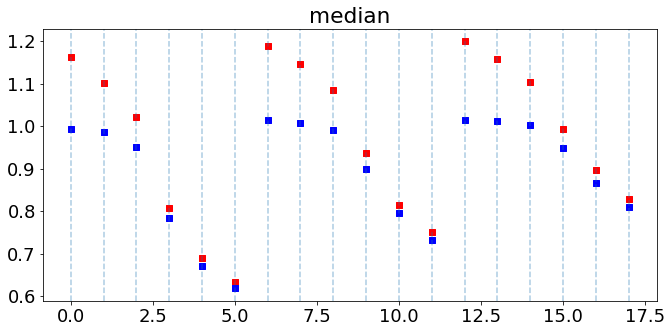

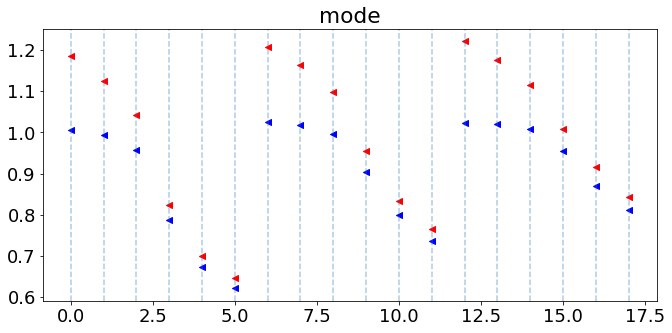

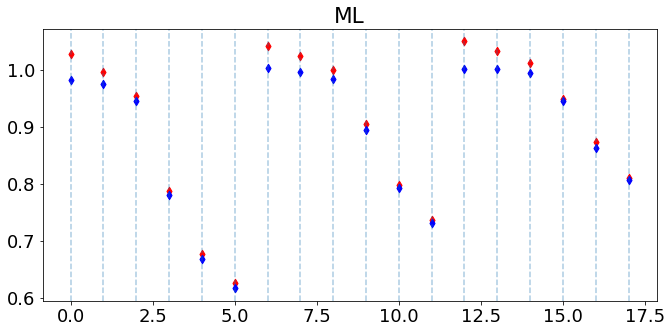

In [6]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs  = [100, 1000]
sigma = [0.3]

gamma = [0.5, 0.6, 0.8, 1.2, 1.4, 1.5]
rs    = [5, 10, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

i=0
for pe in PE:   
    fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if n<200:
                color="red"
            else:
                color="blue"
            for _rs in rs:
                for _g in gamma:
                    data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_final"%(n, s, _g, _rs)), unpack=True)  
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker[i])#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
                    #print(n, _g, _rs)
    i+=1
    #ax.legend()
    #ax.set_xticks(x_axis) 
    #ax.set_xticklabels(['(0.5, 5)', '(0.5, 5)', '(1.4, 5)', '(1.5, 5)', 
    #                    '(0.5, 10)', '(0.6, 10)', '(1.4, 10)', '(1.5, 10)',
    #                    '(0.5, 20)', '(0.6, 20)', '(1.4, 20)', '(1.5, 20)'
    #                   ], rotation=80);


In [57]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs = [100]
sigma = [0.3]

gamma = [0.5, 0.6]#, 0.8,1.2, 1.4, 1.5]
rs    = [5, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3]#, 4, 5, 6, 7, 8, 9, 10, 11]#, 12, 13, 14, 15, 16, 17]


def plot_FSE_pe(path, v, pe, marker, fig=None, ax=None, color=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if color is None:
                if n<200:
                    color="red"
                else:
                    color="blue"
            for _rs in rs:
                for _g in gamma:
                    try:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True) 
                    except:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True)  
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker)#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
    ax.set_xticks(x_axis) 
    #ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
    #                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
    #                   ], rotation=80);
    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)',# '(0.8, 5)', '(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
                        #'(0.5, 10)', '(0.6, 10)', '(0.8, 10)', '(1.2, 10)', '(1.4, 10)', '(1.5, 10)',
                        '(0.5, 20)', '(0.6, 20)', #'(0.8, 20)', '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
                       ], rotation=80);
    return fig, ax

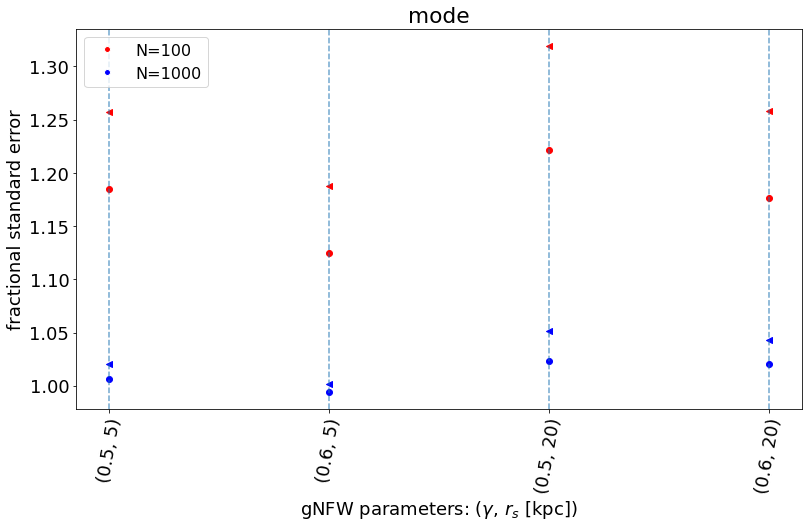

In [51]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(13, 7))

PE = ["mode"]#, "mean", "median", "ML"]
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", pe, "o", fig, ax)
    plot_FSE_pe(path, "final_non_linear", pe, "<", fig, ax)
    #plot_FSE_pe(path, "final_non_linear_wider", pe, "s", fig, ax)
    
    props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
    #ax.text(0.5, 0.08, r"$\sigma_T=10\%$ $\sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=30\%$", 
    #        transform=ax.transAxes, fontsize=18, bbox=props, verticalalignment='top')
    
    legend_elements = [#Line2D([0], [0], marker='o', color='w', markerfacecolor='k', label='Linear error propag.'),
                       #Line2D([0], [0], marker='<', color='w', markerfacecolor='k', label='Non-linear error propag.'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='r', label='N=100'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='b', label='N=1000')
                       ]

    ax.legend(handles=legend_elements, loc='upper left', fontsize=16)
    ax.set_ylabel("fractional standard error")
    ax.set_xlabel(r"gNFW parameters: ($\gamma$, $r_s$ [kpc])")
    
    #fig.savefig("FSE_MAP_sigma0.1.pdf", bbox_inches="tight")

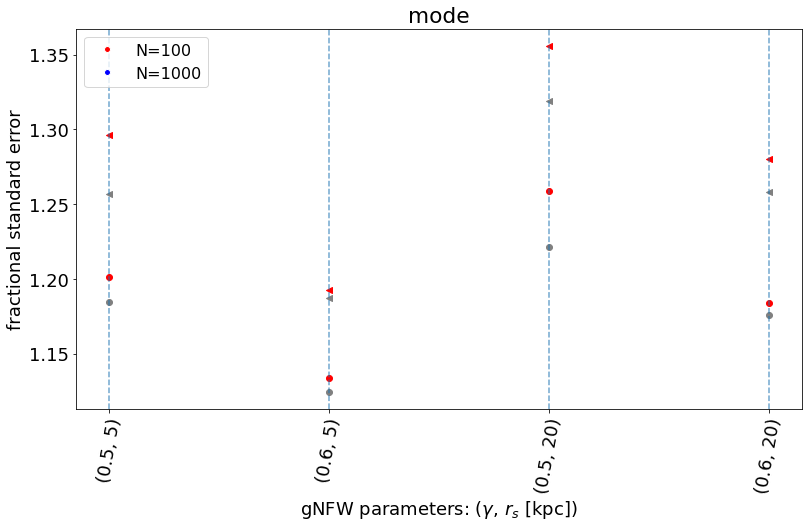

In [59]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(13, 7))

PE = ["mode"]#, "mean", "median", "ML"]
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", pe, "o", fig, ax, color="grey")
    fig, ax = plot_FSE_pe(path, "final_extra_wider", pe, "o", fig, ax)
    plot_FSE_pe(path, "final_non_linear", pe, "<", fig, ax, color="grey")
    plot_FSE_pe(path, "final_non_linear_extra_wider", pe, "<", fig, ax)
    #plot_FSE_pe(path, "final_non_linear_wider", pe, "s", fig, ax)
    
    props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
    #ax.text(0.5, 0.08, r"$\sigma_T=10\%$ $\sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=30\%$", 
    #        transform=ax.transAxes, fontsize=18, bbox=props, verticalalignment='top')
    
    legend_elements = [#Line2D([0], [0], marker='o', color='w', markerfacecolor='k', label='Linear error propag.'),
                       #Line2D([0], [0], marker='<', color='w', markerfacecolor='k', label='Non-linear error propag.'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='r', label='N=100'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='b', label='N=1000')
                       ]

    ax.legend(handles=legend_elements, loc='upper left', fontsize=16)
    ax.set_ylabel("fractional standard error")
    ax.set_xlabel(r"gNFW parameters: ($\gamma$, $r_s$ [kpc])")
    
    #fig.savefig("FSE_MAP_sigma0.1.pdf", bbox_inches="tight")

In [50]:
def plot_coverage_pe(path, ex, n, s, pe, fig=None, ax=None, color=None, ls=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    #ax.set_title(pe)
    x=0
    if color is None:
        if n<200:
            color="red"
        else:
            color="blue"
    i = 0
    for _rs in rs:
        cove = []; x = [];
        for _g in gamma:
            try:
                data = np.genfromtxt(path + "statistics_" + ex +           
                         ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True) 
            except:
                data = np.genfromtxt(path + "statistics_" + ex +           
                         ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True)  
            if pe=="symmetric":                                                       
                low  = data[2]
                high = data[3]
            elif pe=="HPD":                                                       
                low  = data[7]
                high = data[8]
            elif pe=="LI":                                                       
                low  = data[10]
                high = data[11]
            else:                                                                  
                sys.exit("Interval not implemented!") 
                
            one = _g > low
            two = _g < high
            
            cove.append(len(np.where((one==True) & (two==True))[0])/len(data[0]))
            x.append(i); i+=1
                                    
        ax.plot(x, cove, color=color, ls=ls, lw=2.5)#, label="N=%i"%n)
    return fig, ax

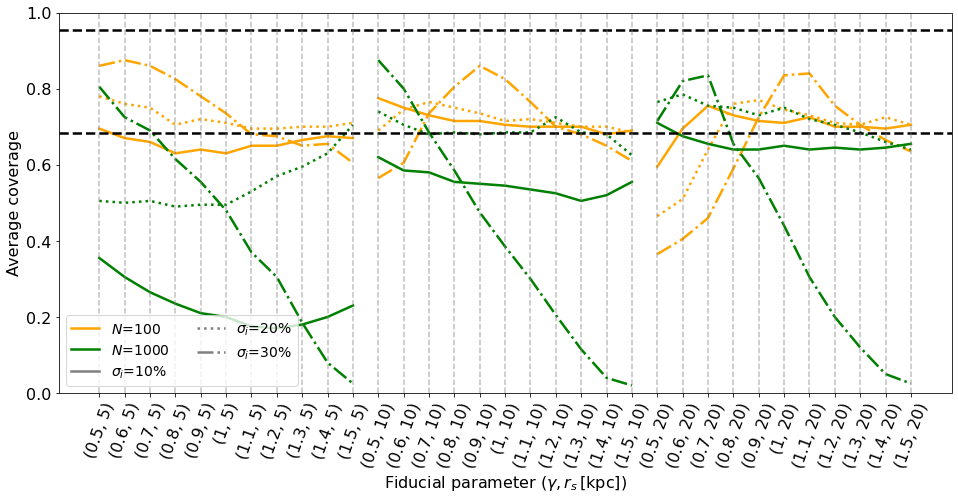

In [59]:
path = "/home/mariacst/exoplanets/results/power_law/"
rc('font', family='times new roman', size=16.)

nBDs = 100
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

PE     = ["HPD"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

pe = "HPD"; ex="baseline_NL_log"

plot_coverage_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
plot_coverage_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
plot_coverage_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
plot_coverage_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
plot_coverage_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_coverage_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")


ax.axhline(0.683, lw=2.5, ls="--", color="black"); ax.axhline(0.954, lw=2.5, ls="--", color="black")
ax.set_xticks(x_axis) 
#ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
#                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
#                   ], rotation=80);
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
ax.set_ylim(0., 1.)
ax.set_ylabel("Average coverage"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='lower left', fontsize=14)

#fig.savefig("coverage2_" + ex + pe + ".png", transparent=True, bbox_inches="tight")

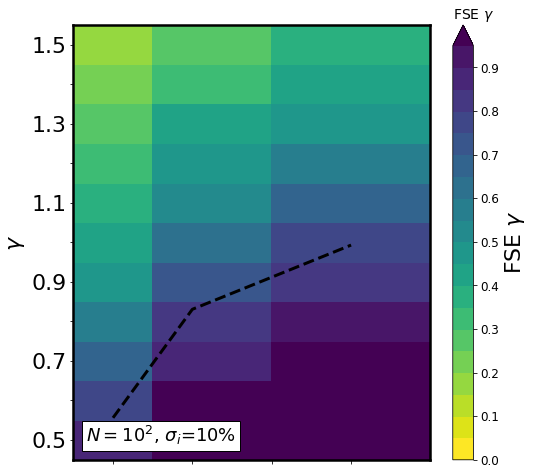

In [12]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "T650_NL_log"

pe = "ML"
    
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
cs = grid_FSE(path, 100, 0.1,  ex, ax, pe, ylabel=True, xlabel=False)

#ax[0, 0].set_title(pe)
ax.set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])

#fig.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(cs)
cbar.set_label(r"FSE $\gamma^{{}}$".format(pe))



cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")

nBDs=100; sigma=0.1; f=1.
rs = [5., 10., 20.]; UL = []; gamma_UL_2sigma_minus=[]
gamma_UL_2sigma_plus=[]; gamma_UL_1sigma_minus=[]; gamma_UL_1sigma_plus=[]

path="../python/data_UL/"
ex="T650"

for _rs in rs:
    data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_steps200_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)
    UL.append(np.median(data)); gamma_UL_1sigma_minus.append(np.percentile(data, 15.85))
    gamma_UL_1sigma_plus.append(np.percentile(data, 84.15)); gamma_UL_2sigma_plus.append(np.percentile(data, 97.7))
    gamma_UL_2sigma_minus.append(np.percentile(data, 2.30))
    
ax.plot(rs, UL, color="k", lw=3., ls="--")

In [4]:
import utils_plots; import importlib
importlib.reload(utils_plots)
from utils_plots import grid_FSE

OSError: /home/mariacst/exoplanets/results/power_law/statistics_2sigma_baseline_log_N100_sigma0.1_gamma0.5rs5.0 not found.

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


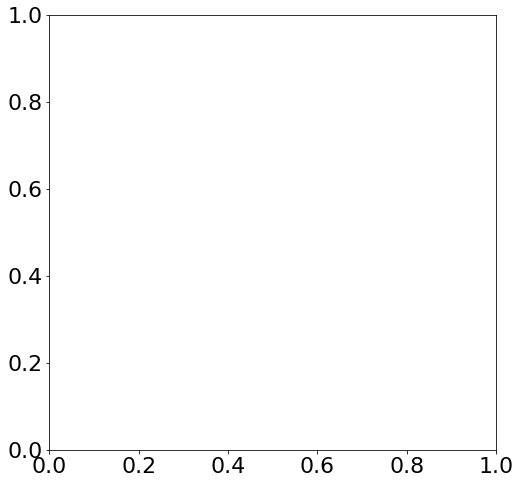

In [5]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "baseline_log"

pe = "HDE"
    
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
cs = grid_FSE(path, 100, 0.1,  ex, ax, pe, ylabel=True, xlabel=False)

#ax[0, 0].set_title(pe)
ax.set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])

#fig.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(cs)
cbar.set_label(r"FSE $\gamma^{{}}$".format(pe))



cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")

# Comparison between gNFW & power-law

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:48: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "background" which is no longer supported as of 3.3 and will become an error two minor releases later


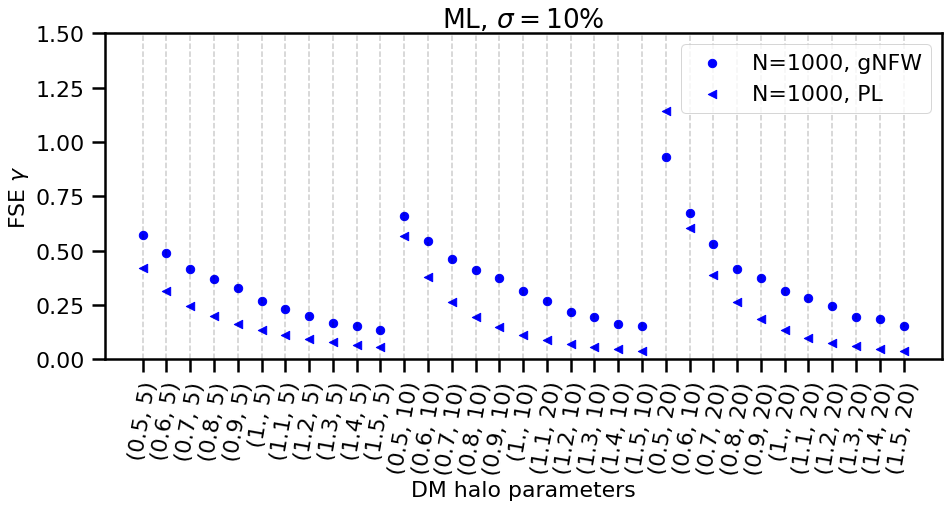

In [15]:
nBDs = [1000]
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

color  = "blue"
marker = ["o", "s", "<", "d"]

j=0

fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
i=0
for N in nBDs:
    path = "/home/mariacst/exoplanets/results/gNFW/"
    xi, yi, zi = FSE_f_gamma_rs_gNFW(path, N, sigma, "baseline_NL_gNFW", _gamma=True)    
    ax.scatter(x1, np.ravel(zi), color=color, marker="o", label="N=%i, gNFW"%N, s=70.)

    path = "/home/mariacst/exoplanets/results/power_law/"
    for N in nBDs:
        xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_log", PE=pe)    
        ax.scatter(x1, np.ravel(zi), color=color, marker="<", label="N=%i, PL"%N, s=70.)


for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x1:
    ax.axvline(i, ls="--", alpha=0.2, color="k")

ax.legend()
ax.set_xticks(x1) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

ax.set_ylim(0, 1.)
ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
ax.set_ylim(0., 1.5)
fig.savefig("baseline_NL_comparison_N%i_sigma%.1f.png"%(N, sigma), bbox_inches="tight", background="transparent")